# Day 6 — Deep Learning + CNN Architectures + RNN/LSTM/GRU + Autoencoder + GAN

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(tf.__version__)

2.20.0


## TensorFlow Tensor Basics

In [2]:
scalar = tf.constant(5)
vector = tf.constant([1,2,3])
matrix = tf.constant([[1,2],[3,4]])

print(scalar.shape)
print(vector.shape)
print(matrix.shape)

()
(3,)
(2, 2)


## Keras Sequential Model

In [3]:
model = keras.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(8, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49 (196.00 B)

 Trainable params: 49 (196.00 B)

 Non-trainable params: 0 (0.00 B)

## Compile / Fit / Evaluate / Predict

In [4]:
X = np.random.rand(200,4).astype("float32")
y = (X.sum(axis=1) > 2).astype("float32")

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.fit(X, y, epochs=3, batch_size=16, verbose=1)

print(model.evaluate(X, y, verbose=0))
print(model.predict(X[:5], verbose=0))

Epoch 1/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5750 - loss: 0.6736
Epoch 2/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5850 - loss: 0.6705
Epoch 3/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6000 - loss: 0.6673
[0.6656548380851746, 0.5950000286102295]
[[0.47632942]
 [0.51919955]
 [0.6676516 ]
 [0.62777615]
 [0.4916816 ]]


## Computer Vision Image Shape

In [5]:
img = np.random.randint(0, 256, (224,224,3), dtype=np.uint8)
print("Shape:", img.shape)

img_norm = img.astype("float32") / 255.0
print("Range:", img_norm.min(), img_norm.max())

Shape: (224, 224, 3)
Range: 0.0 1.0


## Simple CNN

In [6]:
cnn = keras.Sequential([
    layers.Input(shape=(32,32,3)),
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(2),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,250 (1.08 MB)

 Trainable params: 282,250 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

## CNN Forward Pass

In [7]:
dummy = np.random.rand(1,32,32,3).astype("float32")
out = cnn(dummy)
print(out.shape)

(1, 10)


## Convolution Output Size Formula

In [8]:
def conv_output_size(N, F, P, S):
    return int(np.floor((N - F + 2*P)/S) + 1)

print(conv_output_size(32,3,1,1))

32


## AlexNet

In [9]:
def build_alexnet(input_shape=(227,227,3), classes=10):
    return keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(96, 11, strides=4, activation="relu"),
        layers.MaxPooling2D(3, strides=2),
        layers.Conv2D(256, 5, padding="same", activation="relu"),
        layers.MaxPooling2D(3, strides=2),
        layers.Conv2D(384, 3, padding="same", activation="relu"),
        layers.Conv2D(384, 3, padding="same", activation="relu"),
        layers.Conv2D(256, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(3, strides=2),
        layers.Flatten(),
        layers.Dense(4096, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(4096, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(classes, activation="softmax")
    ])

alexnet = build_alexnet()
alexnet.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,322,314 (222.48 MB)

 Trainable params: 58,322,314 (222.48 MB)

 Non-trainable params: 0 (0.00 B)

## AlexNet Memory Map

In [10]:
print("AlexNet: Conv11x11 -> Pool -> Conv5x5 -> Pool -> Conv3x3 x3 -> Pool -> Dense -> Dense -> Output")

AlexNet: Conv11x11 -> Pool -> Conv5x5 -> Pool -> Conv3x3 x3 -> Pool -> Dense -> Dense -> Output


## VGG-16

In [11]:
def build_vgg16(input_shape=(224,224,3), classes=10):
    return keras.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(64,3,padding="same",activation="relu"),
        layers.Conv2D(64,3,padding="same",activation="relu"),
        layers.MaxPooling2D(2),

        layers.Conv2D(128,3,padding="same",activation="relu"),
        layers.Conv2D(128,3,padding="same",activation="relu"),
        layers.MaxPooling2D(2),

        layers.Conv2D(256,3,padding="same",activation="relu"),
        layers.Conv2D(256,3,padding="same",activation="relu"),
        layers.Conv2D(256,3,padding="same",activation="relu"),
        layers.MaxPooling2D(2),

        layers.Conv2D(512,3,padding="same",activation="relu"),
        layers.Conv2D(512,3,padding="same",activation="relu"),
        layers.Conv2D(512,3,padding="same",activation="relu"),
        layers.MaxPooling2D(2),

        layers.Conv2D(512,3,padding="same",activation="relu"),
        layers.Conv2D(512,3,padding="same",activation="relu"),
        layers.Conv2D(512,3,padding="same",activation="relu"),
        layers.MaxPooling2D(2),

        layers.Flatten(),
        layers.Dense(4096, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(4096, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(classes, activation="softmax")
    ])

vgg16 = build_vgg16()
vgg16.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,301,514 (512.32 MB)

 Trainable params: 134,301,514 (512.32 MB)

 Non-trainable params: 0 (0.00 B)

## VGG-16 Built-in

In [12]:
vgg_builtin = tf.keras.applications.VGG16(
    weights=None,
    include_top=False,
    input_shape=(224,224,3)
)
vgg_builtin.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

## GoogLeNet Inception Module

In [13]:
def inception_module(x, f1, f3r, f3, f5r, f5, pool_proj):
    b1 = layers.Conv2D(f1, 1, activation="relu")(x)

    b3 = layers.Conv2D(f3r, 1, activation="relu")(x)
    b3 = layers.Conv2D(f3, 3, padding="same", activation="relu")(b3)

    b5 = layers.Conv2D(f5r, 1, activation="relu")(x)
    b5 = layers.Conv2D(f5, 5, padding="same", activation="relu")(b5)

    bp = layers.MaxPooling2D(3, strides=1, padding="same")(x)
    bp = layers.Conv2D(pool_proj, 1, activation="relu")(bp)

    return layers.Concatenate()([b1,b3,b5,bp])

## GoogLeNet-Style Model

In [14]:
def build_googlenet_style(input_shape=(224,224,3), classes=10):
    inp = layers.Input(shape=input_shape)

    x = layers.Conv2D(64,7,strides=2,padding="same",activation="relu")(inp)
    x = layers.MaxPooling2D(3,strides=2,padding="same")(x)

    x = layers.Conv2D(64,1,activation="relu")(x)
    x = layers.Conv2D(192,3,padding="same",activation="relu")(x)
    x = layers.MaxPooling2D(3,strides=2,padding="same")(x)

    x = inception_module(x,64,96,128,16,32,32)
    x = inception_module(x,128,128,192,32,96,64)

    x = layers.GlobalAveragePooling2D()(x)
    out = layers.Dense(classes, activation="softmax")(x)

    return keras.Model(inp,out)

googlenet = build_googlenet_style()
googlenet.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 112, 112,  │      9,472 │ input_layer_5[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 56, 56,    │          0 │ conv2d_20[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 56, 56,    │      4,160 │ max_pooling2d_10… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 56, 56,    │    110,784 │ conv2d_21[0][0]   │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 28, 28,    │          0 │ conv2d_22[0][0]   │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 28, 28,    │     18,528 │ max_pooling2d_11… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 28, 28,    │      3,088 │ max_pooling2d_11… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 28, 28,    │          0 │ max_pooling2d_11… │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 28, 28,    │     12,352 │ max_pooling2d_11… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 28, 28,    │    110,720 │ conv2d_24[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 28, 28,    │     12,832 │ conv2d_26[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 28, 28,    │      6,176 │ max_pooling2d_12… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 28, 28,    │          0 │ conv2d_23[0][0],  │
│ (Concatenate)       │ 256)              │            │ conv2d_25[0][0],  │
│                     │                   │            │ conv2d_27[0][0],  │
│                     │                   │            │ conv2d_28[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 28, 28,    │     32,896 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 28, 28,    │      8,224 │ concatenate[0][0] │
│                     │ 32)               │            │                 

 Total params: 681,658 (2.60 MB)

 Trainable params: 681,658 (2.60 MB)

 Non-trainable params: 0 (0.00 B)

## GoogLeNet Memory Map

In [15]:
print("Inception: 1x1 branch | 1x1->3x3 | 1x1->5x5 | Pool->1x1 ; then concatenate")

Inception: 1x1 branch | 1x1->3x3 | 1x1->5x5 | Pool->1x1 ; then concatenate


## Residual Block

In [16]:
def residual_block(x, filters, stride=1):
    shortcut = x

    y = layers.Conv2D(filters,3,strides=stride,padding="same",use_bias=False)(x)
    y = layers.BatchNormalization()(y)
    y = layers.ReLU()(y)

    y = layers.Conv2D(filters,3,padding="same",use_bias=False)(y)
    y = layers.BatchNormalization()(y)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters,1,strides=stride,padding="same",use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    y = layers.Add()([y, shortcut])
    y = layers.ReLU()(y)
    return y

## ResNet-Style Model

In [17]:
def build_resnet_style(input_shape=(64,64,3), classes=10):
    inp = layers.Input(shape=input_shape)

    x = layers.Conv2D(64,7,strides=2,padding="same",use_bias=False)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(3,strides=2,padding="same")(x)

    x = residual_block(x,64)
    x = residual_block(x,64)
    x = residual_block(x,128,stride=2)
    x = residual_block(x,128)

    x = layers.GlobalAveragePooling2D()(x)
    out = layers.Dense(classes, activation="softmax")(x)

    return keras.Model(inp,out)

resnet = build_resnet_style()
resnet.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 32, 32,    │      9,408 │ input_layer_6[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │        256 │ conv2d_35[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_14    │ (None, 16, 16,    │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, 16, 16,    │     36,864 │ max_pooling2d_14… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_36[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_37 (Conv2D)  │ (None, 16, 16,    │     36,864 │ re_lu_1[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_37[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ max_pooling2d_14… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 16, 16,    │          0 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 16, 16,    │     36,864 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_38[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 16, 16,    │     36,864 │ re_lu_3[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_39[0][0] 

 Total params: 686,282 (2.62 MB)

 Trainable params: 684,362 (2.61 MB)

 Non-trainable params: 1,920 (7.50 KB)

## ResNet Formula

In [18]:
print("Residual connection formula: y = F(x) + x")

Residual connection formula: y = F(x) + x


## Built-in ResNet50

In [19]:
resnet50 = tf.keras.applications.ResNet50(
    weights=None,
    include_top=False,
    input_shape=(224,224,3)
)
resnet50.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_7[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

## CNN Architecture Comparison

In [20]:
pd.DataFrame({
    "Architecture":["AlexNet","VGG-16","GoogLeNet","ResNet"],
    "Main Idea":[
        "Large early filters + dropout",
        "Deep stack of 3x3 convolutions",
        "Parallel Inception branches",
        "Residual / skip connections"
    ]
})

,Architecture,Main Idea
0,AlexNet,Large early filters + dropout
1,VGG-16,Deep stack of 3x3 convolutions
2,GoogLeNet,Parallel Inception branches
3,ResNet,Residual / skip connections


## Sequence Data

In [21]:
X_seq = np.random.rand(100,10,8).astype("float32")
print(X_seq.shape)

(100, 10, 8)


## Simple RNN

In [22]:
rnn = keras.Sequential([
    layers.Input(shape=(10,8)),
    layers.SimpleRNN(16),
    layers.Dense(1, activation="sigmoid")
])
rnn.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417 (1.63 KB)

 Trainable params: 417 (1.63 KB)

 Non-trainable params: 0 (0.00 B)

## RNN Equation

In [23]:
print("h_t = tanh(W_xh x_t + W_hh h_(t-1) + b_h)")
print("y_t = W_hy h_t + b_y")

h_t = tanh(W_xh x_t + W_hh h_(t-1) + b_h)
y_t = W_hy h_t + b_y


## LSTM

In [24]:
lstm = keras.Sequential([
    layers.Input(shape=(10,8)),
    layers.LSTM(16),
    layers.Dense(1, activation="sigmoid")
])
lstm.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,617 (6.32 KB)

 Trainable params: 1,617 (6.32 KB)

 Non-trainable params: 0 (0.00 B)

## LSTM Equations

In [25]:
print("f_t = sigmoid(W_f[h_(t-1),x_t] + b_f)")
print("i_t = sigmoid(W_i[h_(t-1),x_t] + b_i)")
print("C_t = f_t*C_(t-1) + i_t*C~_t")
print("o_t = sigmoid(W_o[h_(t-1),x_t] + b_o)")
print("h_t = o_t*tanh(C_t)")

f_t = sigmoid(W_f[h_(t-1),x_t] + b_f)
i_t = sigmoid(W_i[h_(t-1),x_t] + b_i)
C_t = f_t*C_(t-1) + i_t*C~_t
o_t = sigmoid(W_o[h_(t-1),x_t] + b_o)
h_t = o_t*tanh(C_t)


## GRU

In [26]:
gru = keras.Sequential([
    layers.Input(shape=(10,8)),
    layers.GRU(16),
    layers.Dense(1, activation="sigmoid")
])
gru.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 16)             │         1,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,265 (4.94 KB)

 Trainable params: 1,265 (4.94 KB)

 Non-trainable params: 0 (0.00 B)

## GRU Equations

In [27]:
print("z_t = sigmoid(W_z[h_(t-1),x_t] + b_z)")
print("r_t = sigmoid(W_r[h_(t-1),x_t] + b_r)")
print("h_t = (1-z_t)h_(t-1) + z_t*h~_t")

z_t = sigmoid(W_z[h_(t-1),x_t] + b_z)
r_t = sigmoid(W_r[h_(t-1),x_t] + b_r)
h_t = (1-z_t)h_(t-1) + z_t*h~_t


## Autoencoder

In [28]:
input_dim = 20
latent_dim = 5

inp = layers.Input(shape=(input_dim,))
x = layers.Dense(12, activation="relu")(inp)
latent = layers.Dense(latent_dim, activation="relu")(x)

x = layers.Dense(12, activation="relu")(latent)
out = layers.Dense(input_dim, activation="sigmoid")(x)

autoencoder = keras.Model(inp,out)
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 12)             │           252 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 5)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 12)             │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 20)             │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 649 (2.54 KB)

 Trainable params: 649 (2.54 KB)

 Non-trainable params: 0 (0.00 B)

## Train Autoencoder

In [29]:
X_auto = np.random.rand(500,input_dim).astype("float32")

autoencoder.fit(
    X_auto, X_auto,
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0859
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0839 
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0833 
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0827 
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0822


## Autoencoder Reconstruction

In [30]:
original = X_auto[:1]
recon = autoencoder.predict(original, verbose=0)

print("Reconstruction MSE:", np.mean((original-recon)**2))

Reconstruction MSE: 0.09184368


## Autoencoder Formulas

In [31]:
print("Encoder: z = f(W_e x + b_e)")
print("Decoder: x_hat = g(W_d z + b_d)")
print("Loss: L = (1/n) sum (x - x_hat)^2")

Encoder: z = f(W_e x + b_e)
Decoder: x_hat = g(W_d z + b_d)
Loss: L = (1/n) sum (x - x_hat)^2


## GAN Generator

In [32]:
latent_dim = 16

generator = keras.Sequential([
    layers.Input(shape=(latent_dim,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(28*28, activation="sigmoid"),
    layers.Reshape((28,28,1))
])

generator.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 784)            │        50,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,616 (209.44 KB)

 Trainable params: 53,616 (209.44 KB)

 Non-trainable params: 0 (0.00 B)

## GAN Discriminator

In [33]:
discriminator = keras.Sequential([
    layers.Input(shape=(28,28,1)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

discriminator.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,305 (196.50 KB)

 Trainable params: 50,305 (196.50 KB)

 Non-trainable params: 0 (0.00 B)

## Generate Fake Image

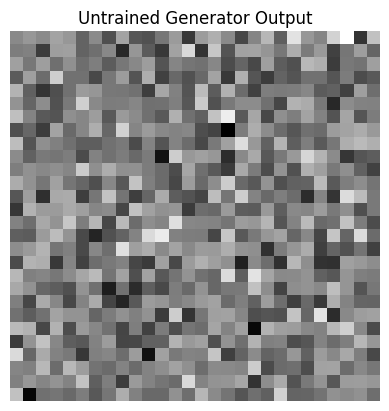

Discriminator score: 0.5191306471824646


In [34]:
noise = tf.random.normal((1,latent_dim))
fake = generator(noise, training=False)

plt.imshow(fake[0,:,:,0], cmap="gray")
plt.axis("off")
plt.title("Untrained Generator Output")
plt.show()

print("Discriminator score:", float(discriminator(fake, training=False)[0][0]))

## GAN Objective

In [35]:
print("x_fake = G(z)")
print("Classic objective: min_G max_D [ E log D(x) + E log(1 - D(G(z))) ]")

x_fake = G(z)
Classic objective: min_G max_D [ E log D(x) + E log(1 - D(G(z))) ]


## Final Summary

In [36]:
pd.DataFrame({
    "Topic":[
        "TensorFlow","Keras","CNN","AlexNet","VGG-16","GoogLeNet","ResNet",
        "RNN","LSTM","GRU","Autoencoder","GAN"
    ],
    "Memory Point":[
        "DL framework","High-level API","Image/spatial learning",
        "Early deep CNN","3x3 conv stacks","Inception multi-branch",
        "Skip connections","Sequence memory","Long-term gated memory",
        "Simpler gated RNN","Compress/reconstruct","Generator vs discriminator"
    ]
})

,Topic,Memory Point
0,TensorFlow,DL framework
1,Keras,High-level API
2,CNN,Image/spatial learning
3,AlexNet,Early deep CNN
4,VGG-16,3x3 conv stacks
5,GoogLeNet,Inception multi-branch
6,ResNet,Skip connections
7,RNN,Sequence memory
8,LSTM,Long-term gated memory
9,GRU,Simpler gated RNN
